In [1]:
#Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
# Step 2: Load Dataset
import pandas as pd

df = pd.read_csv(r"C:\Users\kashi\Downloads\spambase - spambase.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (4601, 58)
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_;  char_freq_(  \
0             0.00            0.00  ...      

In [5]:
#Step 3: Data Cleaning
print("Missing values:\n", df.isnull().sum())

df = df.drop_duplicates()

print("Target values:\n", df.iloc[:, -1].value_counts())

Missing values:
 word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet       

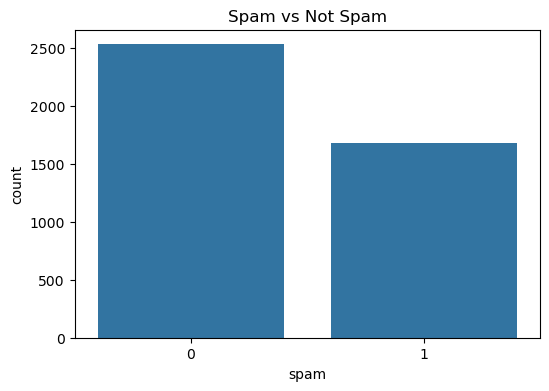

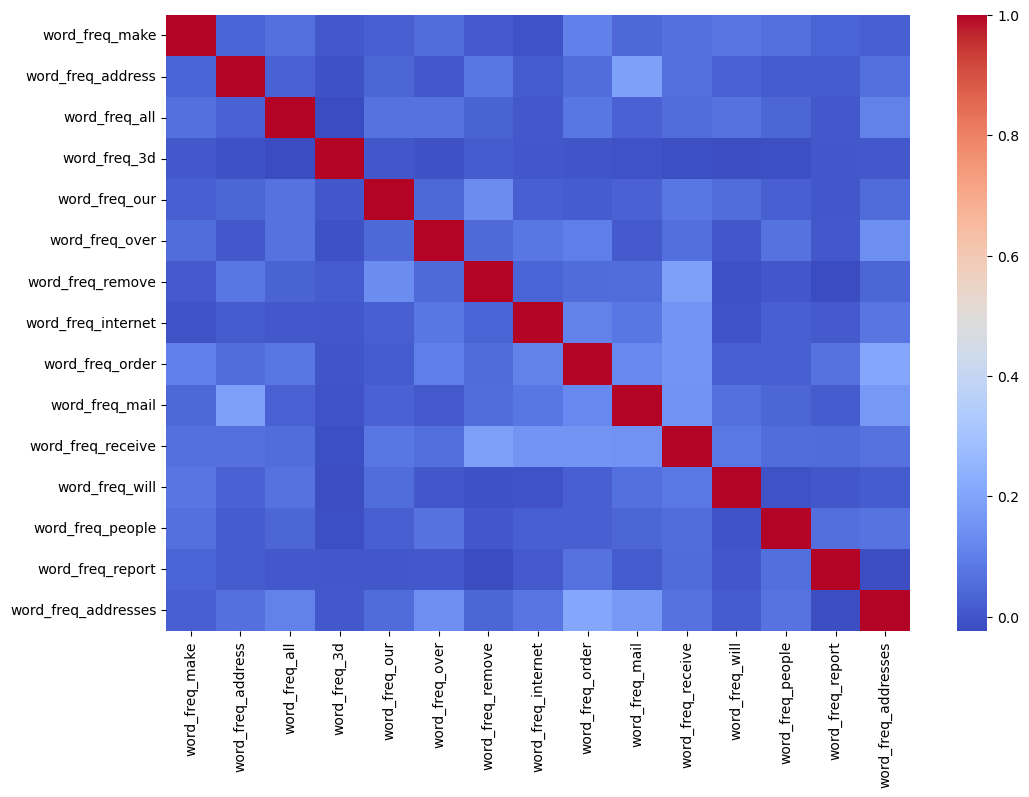

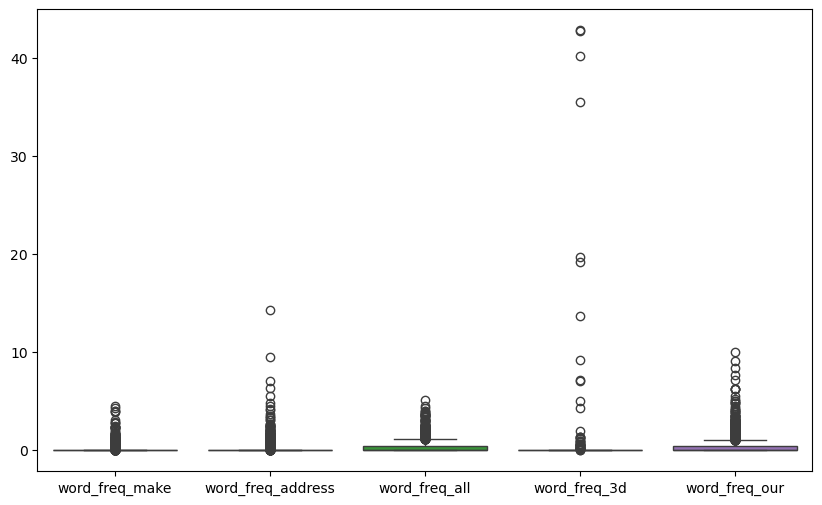

In [6]:
#Step 4: Exploratory Data Analysis
plt.figure(figsize=(6,4))
sns.countplot(x=df.iloc[:, -1])
plt.title("Spam vs Not Spam")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.iloc[:, :15].corr(), cmap="coolwarm")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df.iloc[:, :5])
plt.show()

In [7]:
#Step 5: Feature and Target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [8]:
#Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(    X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
#Step 7: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
#Step 8: Model Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [11]:
#Step 9: Prediction
y_pred = model.predict(X_test_scaled)

In [12]:
#Step 10: Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9346793349168646
Confusion Matrix:
 [[483  23]
 [ 32 304]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.95       506
           1       0.93      0.90      0.92       336

    accuracy                           0.93       842
   macro avg       0.93      0.93      0.93       842
weighted avg       0.93      0.93      0.93       842

